In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [32]:
file = "AT-Dataset\AT Dataset.csv"
df = pd.read_csv(file)

# Exploratory Data Analysis

In [33]:
print("--- First 5 Rows of the DataFrame ---")
print(df.head())
print("\n" + "="*100 + "\n")

print("--- DataFrame Info (Data Types and Non-Null Counts) ---")
df.info()
print("\n" + "="*100 + "\n")

print("--- Count of Missing Values per Column ---")
print(df.isnull().sum())
print("\n" + "="*100 + "\n")

print("--- Summary Statistics for Numerical Columns ---")
print(df.describe())

--- First 5 Rows of the DataFrame ---
          utc_timestamp  AT_load_actual_entsoe_power_statistics  week  \
0  2011-01-01T00:00:00Z                                  6938.0     5   
1  2011-01-01T01:00:00Z                                  6575.0     5   
2  2011-01-01T02:00:00Z                                  6234.0     5   
3  2011-01-01T03:00:00Z                                  6126.0     5   
4  2011-01-01T04:00:00Z                                  6141.0     5   

         mean         std  
0  8229.03836  1257.86589  
1  8229.03836  1257.86589  
2  8229.03836  1257.86589  
3  8229.03836  1257.86589  
4  8229.03836  1257.86589  


--- DataFrame Info (Data Types and Non-Null Counts) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 5 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   utc_timestamp                           52608 

In [34]:
df.head()

,utc_timestamp,AT_load_actual_entsoe_power_statistics,week,mean,std
0,2011-01-01T00:00:00Z,6938.0,5,8229.03836,1257.86589
1,2011-01-01T01:00:00Z,6575.0,5,8229.03836,1257.86589
2,2011-01-01T02:00:00Z,6234.0,5,8229.03836,1257.86589
3,2011-01-01T03:00:00Z,6126.0,5,8229.03836,1257.86589
4,2011-01-01T04:00:00Z,6141.0,5,8229.03836,1257.86589


In [35]:
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'])


In [36]:
print("--- Data type of 'date' column after correction ---")
print(df.dtypes)


--- Data type of 'date' column after correction ---
utc_timestamp                             datetime64[ns, UTC]
AT_load_actual_entsoe_power_statistics                float64
week                                                    int64
mean                                                  float64
std                                                   float64
dtype: object


In [37]:
# Check the first few rows to see the result
print("\n--- First 5 rows ---")
print(df.head())


--- First 5 rows ---
              utc_timestamp  AT_load_actual_entsoe_power_statistics  week  \
0 2011-01-01 00:00:00+00:00                                  6938.0     5   
1 2011-01-01 01:00:00+00:00                                  6575.0     5   
2 2011-01-01 02:00:00+00:00                                  6234.0     5   
3 2011-01-01 03:00:00+00:00                                  6126.0     5   
4 2011-01-01 04:00:00+00:00                                  6141.0     5   

         mean         std  
0  8229.03836  1257.86589  
1  8229.03836  1257.86589  
2  8229.03836  1257.86589  
3  8229.03836  1257.86589  
4  8229.03836  1257.86589  


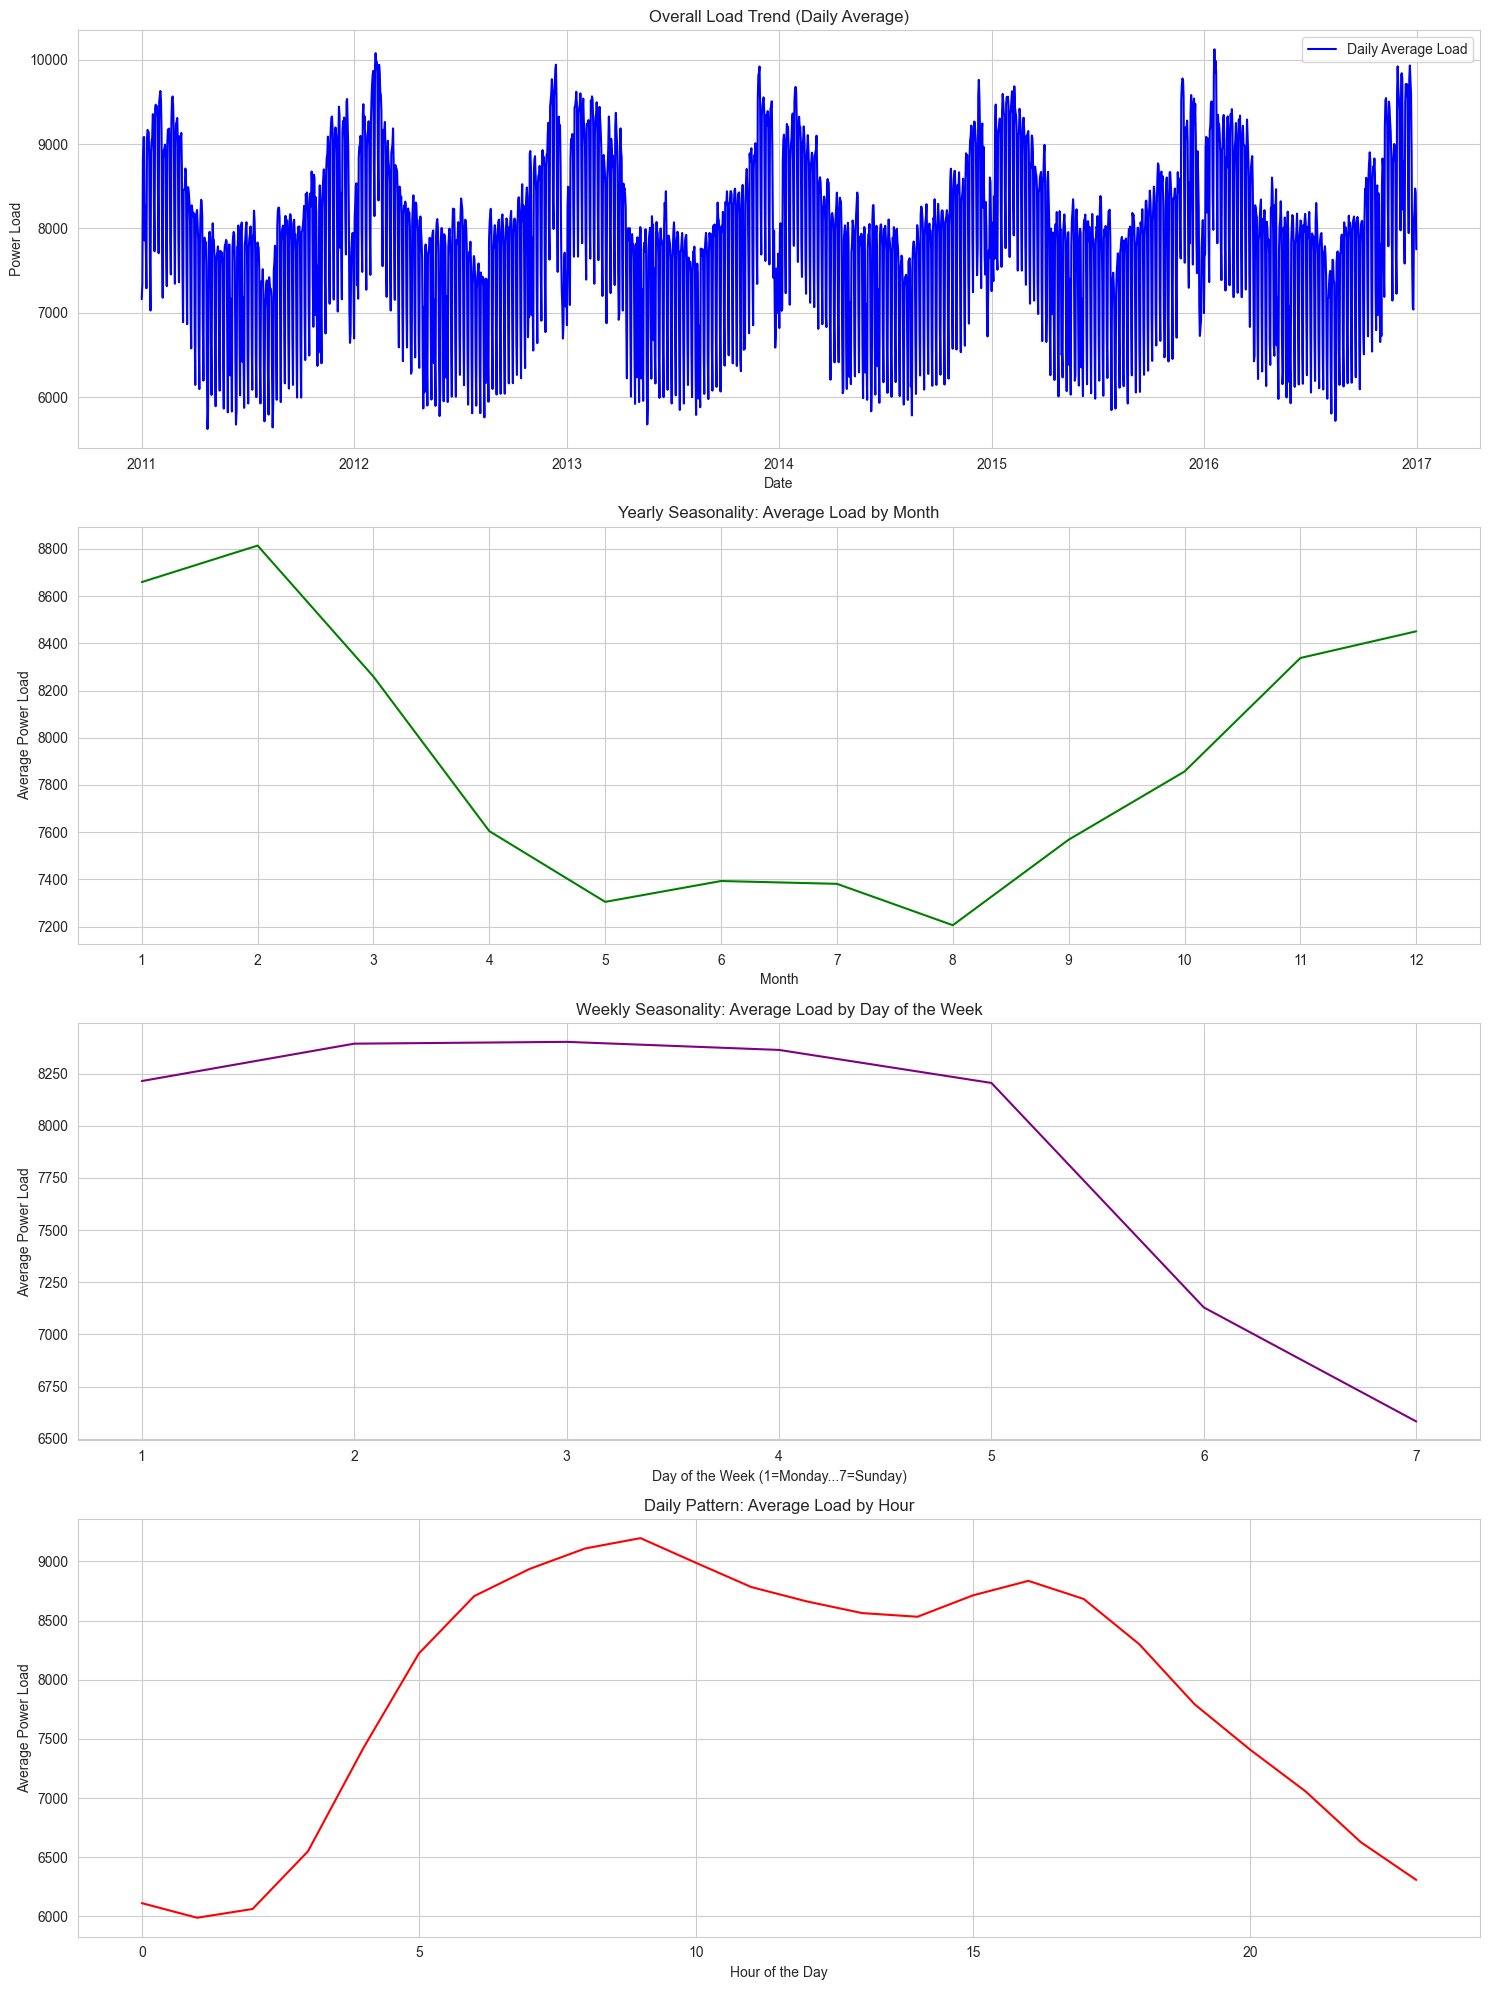

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Preparation ---

# Ensure the timestamp column is in datetime format (important step)
df['utc_timestamp'] = pd.to_datetime(df['utc_timestamp'])

# Set the 'utc_timestamp' column as the index
df.set_index('utc_timestamp', inplace=True)

# *** NEW: Create time-based features from the index ***
# Your new DataFrame doesn't have these columns, so we create them.
df['month'] = df.index.month
df['weekday'] = df.index.dayofweek + 1  # dayofweek is Mon=0...Sun=6, so we add 1
df['hour'] = df.index.hour

# --- Plotting ---

# Set a style for the plots
sns.set_style("whitegrid")

# Create a figure with a 4x1 grid of subplots
fig, axes = plt.subplots(4, 1, figsize=(15, 20))

# --- 1. Overall Trend ---
# Updated column name for plotting
axes[0].plot(df['AT_load_actual_entsoe_power_statistics'].resample('D').mean(), label='Daily Average Load', color='blue')
axes[0].set_title('Overall Load Trend (Daily Average)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Power Load')
axes[0].legend()

# --- 2. Yearly Seasonality (Monthly Pattern) ---
# Updated column names for plotting
sns.lineplot(x='month', y='AT_load_actual_entsoe_power_statistics', data=df, ax=axes[1], errorbar=None, color='green')
axes[1].set_title('Yearly Seasonality: Average Load by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Average Power Load')
axes[1].set_xticks(range(1, 13))

# --- 3. Weekly Seasonality ---
# Updated column names and x-axis label
sns.lineplot(x='weekday', y='AT_load_actual_entsoe_power_statistics', data=df, ax=axes[2], errorbar=None, color='purple')
axes[2].set_title('Weekly Seasonality: Average Load by Day of the Week')
axes[2].set_xlabel('Day of the Week (1=Monday...7=Sunday)')
axes[2].set_ylabel('Average Power Load')

# --- 4. Daily (Intraday) Pattern ---
# Updated column names for plotting
sns.lineplot(x='hour', y='AT_load_actual_entsoe_power_statistics', data=df, ax=axes[3], errorbar=None, color='red')
axes[3].set_title('Daily Pattern: Average Load by Hour')
axes[3].set_xlabel('Hour of the Day')
axes[3].set_ylabel('Average Power Load')

# Adjust layout to prevent plots from overlapping
plt.tight_layout()
plt.show()

In [46]:
df.head(50)

,AT_load_actual_entsoe_power_statistics,week,mean,std,month,weekday,hour,year,day
utc_timestamp,,,,,,,,,
2011-01-01 00:00:00+00:00,6938.0,5,8229.03836,1257.86589,1,6,0,2011,1
2011-01-01 01:00:00+00:00,6575.0,5,8229.03836,1257.86589,1,6,1,2011,1
2011-01-01 02:00:00+00:00,6234.0,5,8229.03836,1257.86589,1,6,2,2011,1
2011-01-01 03:00:00+00:00,6126.0,5,8229.03836,1257.86589,1,6,3,2011,1
2011-01-01 04:00:00+00:00,6141.0,5,8229.03836,1257.86589,1,6,4,2011,1
2011-01-01 05:00:00+00:00,6065.0,5,8229.03836,1257.86589,1,6,5,2011,1
2011-01-01 06:00:00+00:00,6353.0,5,8229.03836,1257.86589,1,6,6,2011,1
2011-01-01 07:00:00+00:00,6738.0,5,8229.03836,1257.86589,1,6,7,2011,1
2011-01-01 08:00:00+00:00,7200.0,5,8229.03836,1257.86589,1,6,8,2011,1


In [58]:
df.rename(columns={'AT_load_actual_entsoe_power_statistics': 'load'}, inplace=True)
df.head()

,load,week,mean,std,month,weekday,hour,year,day
utc_timestamp,,,,,,,,,
2011-01-01 00:00:00+00:00,6938.0,5,8229.03836,1257.86589,1,6,0,2011,1
2011-01-01 01:00:00+00:00,6575.0,5,8229.03836,1257.86589,1,6,1,2011,1
2011-01-01 02:00:00+00:00,6234.0,5,8229.03836,1257.86589,1,6,2,2011,1
2011-01-01 03:00:00+00:00,6126.0,5,8229.03836,1257.86589,1,6,3,2011,1
2011-01-01 04:00:00+00:00,6141.0,5,8229.03836,1257.86589,1,6,4,2011,1


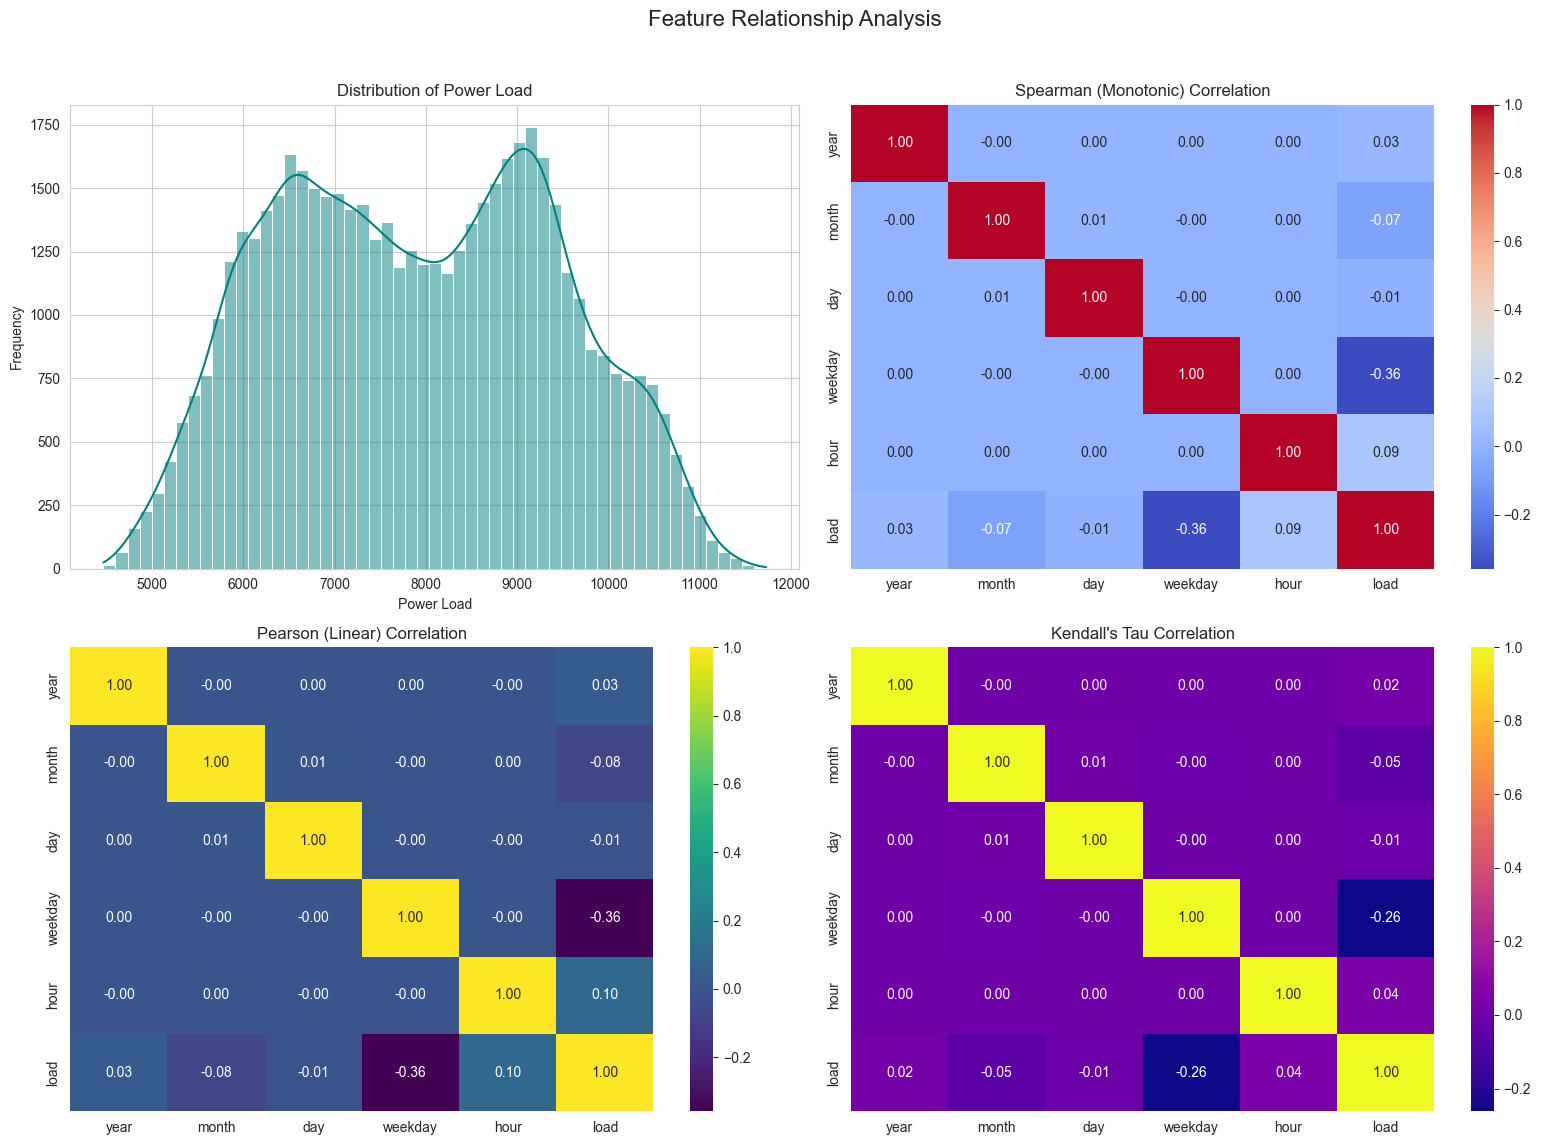

In [60]:
# Reset index to use 'date' and other columns easily in seaborn plots
# This undoes the set_index from the previous step, which is fine for these plots.
# df.reset_index(inplace=True)

# Set a style for the plots
sns.set_style("whitegrid")

# Create a figure with a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Feature Relationship Analysis', fontsize=16)

# --- 1. Distribution of Power Load (Top-Left) ---
sns.histplot(df['load'], kde=True, ax=axes[0, 0], color='teal')
axes[0, 0].set_title('Distribution of Power Load')
axes[0, 0].set_xlabel('Power Load')
axes[0, 0].set_ylabel('Frequency')

# --- Define columns for correlation matrices ---
# NOTE: 'temperature' is removed, and 'demand' is updated.
numerical_cols = ['year', 'month', 'day', 'weekday', 'hour', 'load']

# --- 2. Spearman Correlation Heatmap (Top-Right) ---
spearman_corr = df[numerical_cols].corr(method='spearman')
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Spearman (Monotonic) Correlation')

# --- 3. Pearson Correlation Heatmap (Bottom-Left) ---
pearson_corr = df[numerical_cols].corr(method='pearson')
sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='viridis', ax=axes[1, 0])
axes[1, 0].set_title('Pearson (Linear) Correlation')

# --- 4. Kendall's Tau Correlation Heatmap (Bottom-Right) ---
kendall_corr = df[numerical_cols].corr(method='kendall')
sns.heatmap(kendall_corr, annot=True, fmt='.2f', cmap='plasma', ax=axes[1, 1])
axes[1, 1].set_title("Kendall's Tau Correlation")

# Display the plots
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

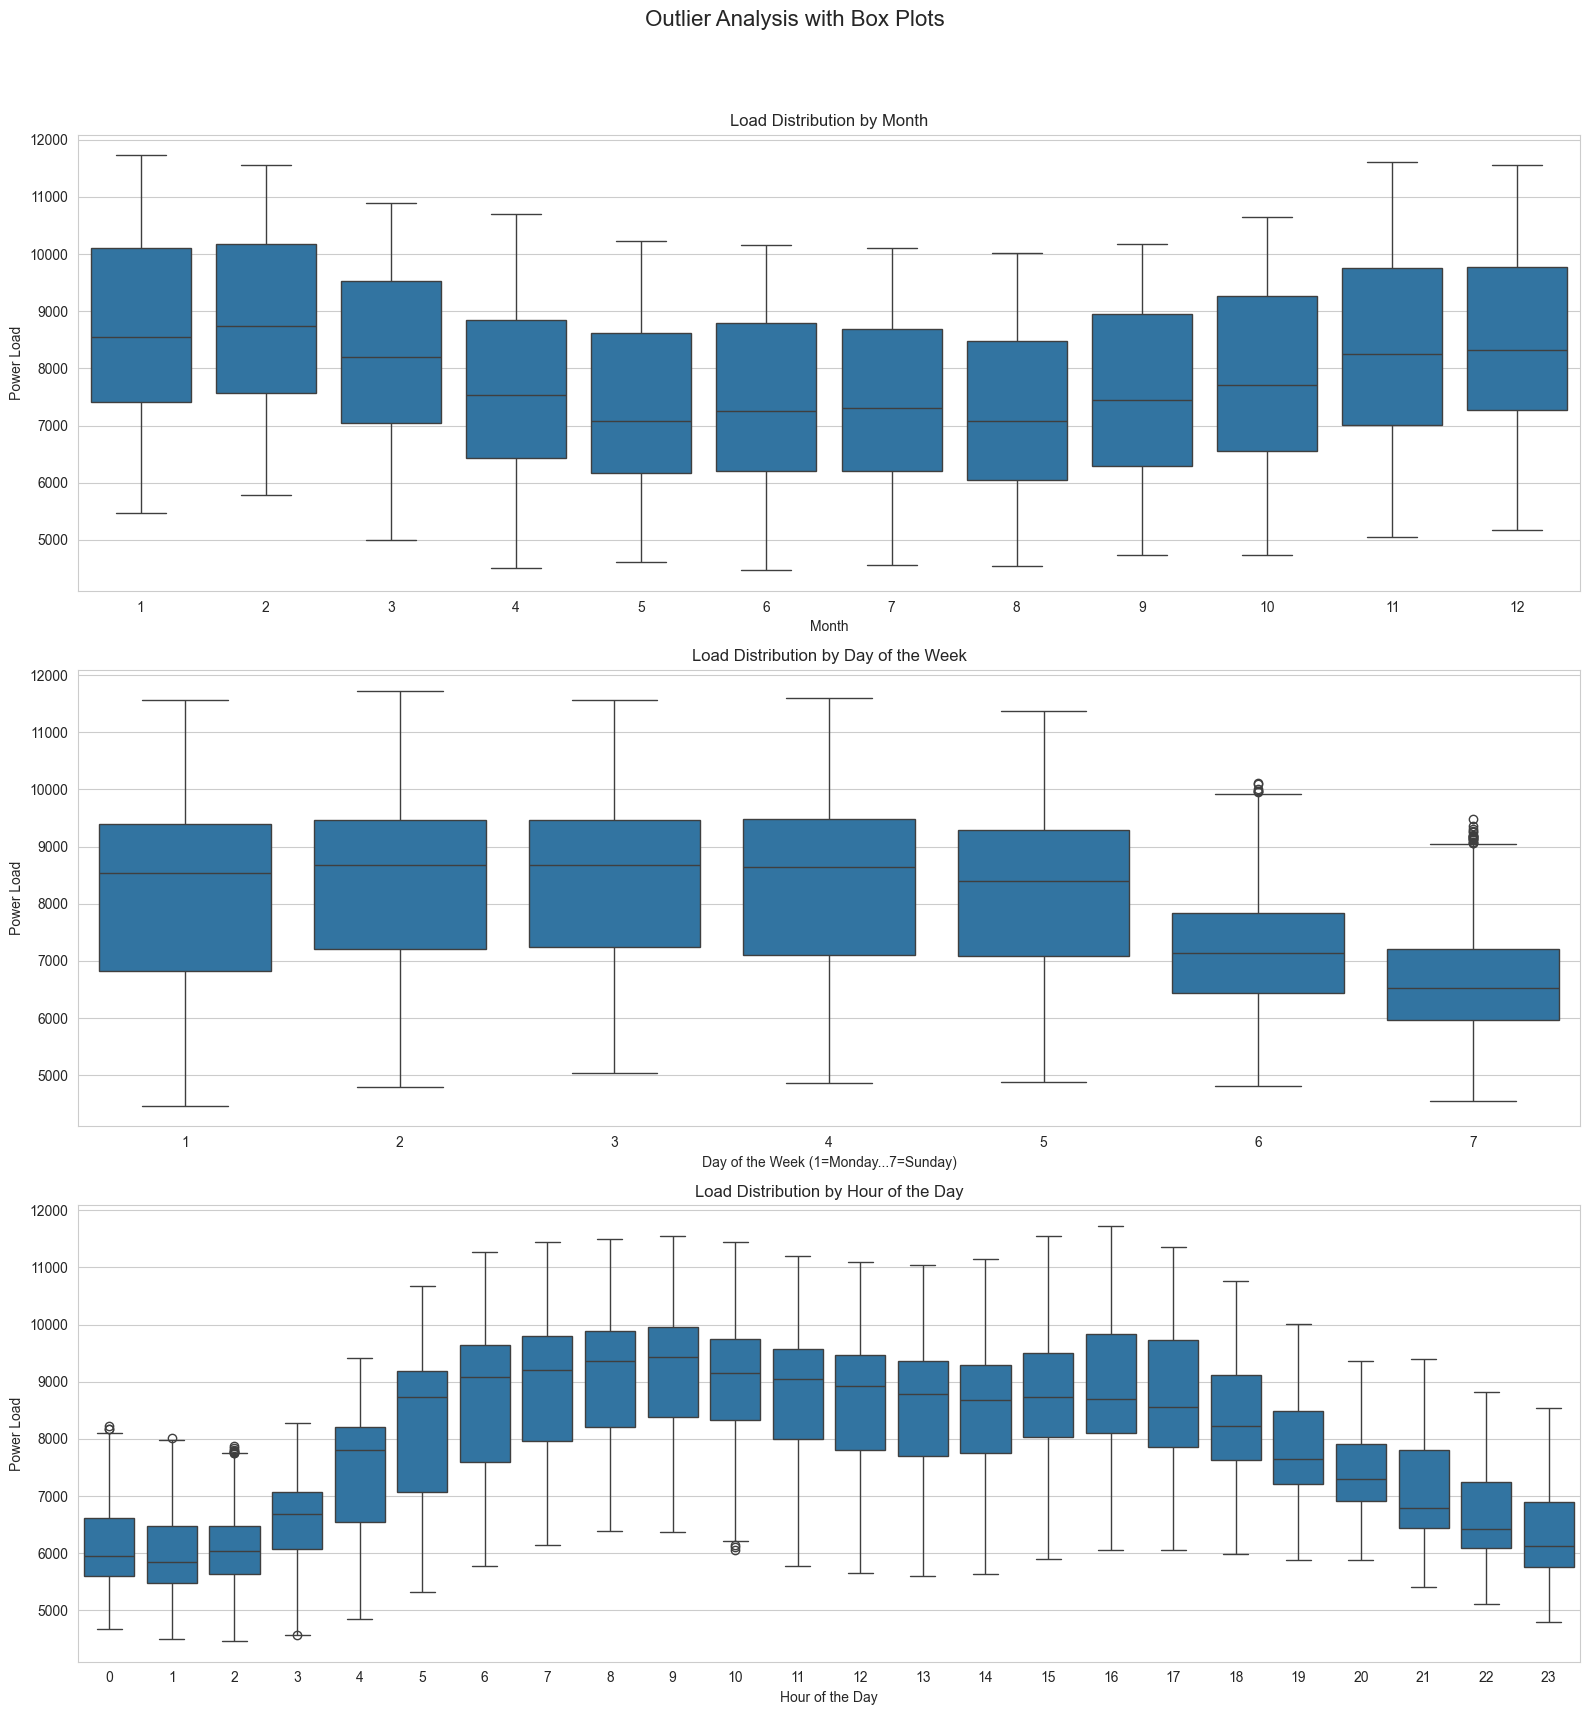

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data Preparation ---
# The following lines ensure the required columns ('month', 'weekday', 'hour') exist.
# This might be redundant if you ran the previous step, but it makes the script safe to run independently.
if not isinstance(df.index, pd.DatetimeIndex):
    df['utc_timestamp'] = pd.to_datetime(df.get('utc_timestamp', df.index))
    df.set_index('utc_timestamp', inplace=True)

df['month'] = df.index.month
df['weekday'] = df.index.dayofweek + 1  # dayofweek is Mon=0...Sun=6, so we add 1
df['hour'] = df.index.hour

# --- Plotting ---

# Set the plot style
sns.set_style("whitegrid")

# Create a figure for our plots
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle('Outlier Analysis with Box Plots', fontsize=16)

# --- 1. Box Plot of Load by Month ---
# Updated 'y' parameter and y-axis label
sns.boxplot(x='month', y='load', data=df, ax=axes[0])
axes[0].set_title('Load Distribution by Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Power Load')

# --- 2. Box Plot of Load by Weekday ---
# Updated 'y' parameter and labels
sns.boxplot(x='weekday', y='load', data=df, ax=axes[1])
axes[1].set_title('Load Distribution by Day of the Week')
axes[1].set_xlabel('Day of the Week (1=Monday...7=Sunday)')
axes[1].set_ylabel('Power Load')

# --- 3. Box Plot of Load by Hour ---
# Updated 'y' parameter and y-axis label
sns.boxplot(x='hour', y='load', data=df, ax=axes[2])
axes[2].set_title('Load Distribution by Hour of the Day')
axes[2].set_xlabel('Hour of the Day')
axes[2].set_ylabel('Power Load')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()